## Markdown

# Phase 7: Feature Engineering

## Objective

The goal of feature engineering is to create additional meaningful features from the existing dataset that may improve the performance of machine learning models.

### Features Created

- Large Transaction
- Log Amount
- Amount Level
- Approximate Hour (Optional)

Dataset Used:
- creditcard_cleaned.csv

## Import Libraries

In [37]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

## Load Clean Dataset


In [38]:
df = pd.read_csv("../data/processed/creditcard_cleaned.csv")
original_df = pd.read_csv("../data/raw/creditcard.csv")
df["Original_Amount"] = original_df["Amount"]

### Verify

In [39]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V22,V23,V24,V25,V26,V27,V28,Amount,Class,Original_Amount
0,-1.996823,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,0.244200,0,149.62
1,-1.996823,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,-0.342584,0,2.69
2,-1.996802,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,1.158900,0,378.66
3,-1.996802,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,0.139886,0,123.50
4,-1.996781,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,-0.073813,0,69.99


## Dataset Information

In [40]:
print("Shape:", df.shape)

df.info()

Shape: (283726, 32)
<class 'pandas.DataFrame'>
RangeIndex: 283726 entries, 0 to 283725
Data columns (total 32 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   Time             283726 non-null  float64
 1   V1               283726 non-null  float64
 2   V2               283726 non-null  float64
 3   V3               283726 non-null  float64
 4   V4               283726 non-null  float64
 5   V5               283726 non-null  float64
 6   V6               283726 non-null  float64
 7   V7               283726 non-null  float64
 8   V8               283726 non-null  float64
 9   V9               283726 non-null  float64
 10  V10              283726 non-null  float64
 11  V11              283726 non-null  float64
 12  V12              283726 non-null  float64
 13  V13              283726 non-null  float64
 14  V14              283726 non-null  float64
 15  V15              283726 non-null  float64
 16  V16              283726 non-n

## Observation

The cleaned dataset was successfully loaded and contains no missing values or duplicate records.

## Create Feature 1 (Large Transaction)

In [41]:
threshold = df["Original_Amount"].quantile(0.95)

df["Large_Transaction"] = (
    df["Original_Amount"] > threshold
).astype(int)

## Cell 7

In [42]:
df["Large_Transaction"] = (df["Original_Amount"] > threshold).astype(int)

### Verify

In [43]:
df["Large_Transaction"].value_counts()

Large_Transaction
0    269539
1     14187
Name: count, dtype: int64

## Create Feature 2 (Log Amount)

In [44]:
df["Log_Amount"] = np.log1p(df["Original_Amount"])

### Verify

In [45]:
df[["Original_Amount","Log_Amount"]].head()

,Original_Amount,Log_Amount
0,149.62,5.014760
1,2.69,1.305626
2,378.66,5.939276
3,123.50,4.824306
4,69.99,4.262539


## Observation

Log transformation reduces the skewness of transaction amounts and may improve model performance.

## Create Feature 3 (Amount Level)

In [46]:
df["Amount_Level"] = pd.qcut(
    df["Original_Amount"],
    q=4,
    labels=["Low", "Medium", "High", "Very High"]
)

### Verify

In [47]:
df[["Original_Amount", "Log_Amount", "Amount_Level"]].head()

,Original_Amount,Log_Amount,Amount_Level
0,149.62,5.014760,Very High
1,2.69,1.305626,Low
2,378.66,5.939276,Very High
3,123.50,4.824306,Very High
4,69.99,4.262539,High


## Observation

Transactions are categorized into four groups based on their relative transaction amounts.

##  (Optional) Approximate Hour Feature

## Note

The original dataset only contains elapsed seconds from the first transaction and not actual timestamps. Therefore, meaningful Hour of Day and Weekend features cannot be generated after scaling Time.

## View New Dataset

In [48]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V25,V26,V27,V28,Amount,Class,Original_Amount,Large_Transaction,Log_Amount,Amount_Level
0,-1.996823,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,0.128539,-0.189115,0.133558,-0.021053,0.244200,0,149.62,0,5.014760,Very High
1,-1.996823,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,0.167170,0.125895,-0.008983,0.014724,-0.342584,0,2.69,0,1.305626,Low
2,-1.996802,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,-0.327642,-0.139097,-0.055353,-0.059752,1.158900,0,378.66,1,5.939276,Very High
3,-1.996802,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,0.647376,-0.221929,0.062723,0.061458,0.139886,0,123.50,0,4.824306,Very High
4,-1.996781,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.206010,0.502292,0.219422,0.215153,-0.073813,0,69.99,0,4.262539,High


## Dataset Information

In [49]:
print(df.shape)

(283726, 35)


## Feature Distribution (Large Transaction)

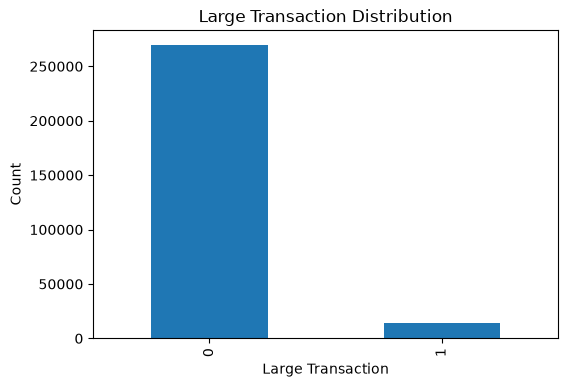

In [50]:
plt.figure(figsize=(6,4))

df["Large_Transaction"].value_counts().plot(kind="bar")

plt.title("Large Transaction Distribution")

plt.xlabel("Large Transaction")

plt.ylabel("Count")

plt.show()

## Amount Level Distribution

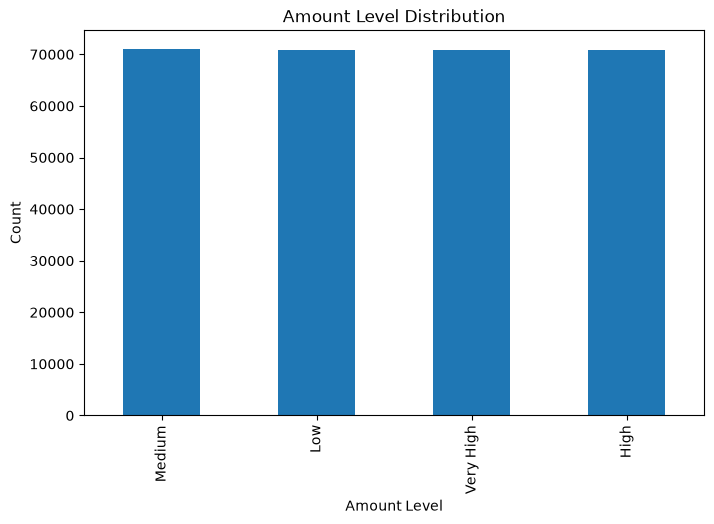

In [51]:
plt.figure(figsize=(8,5))

df["Amount_Level"].value_counts().plot(kind="bar")

plt.title("Amount Level Distribution")

plt.xlabel("Amount Level")

plt.ylabel("Count")

plt.show()

## Log Amount Histogram

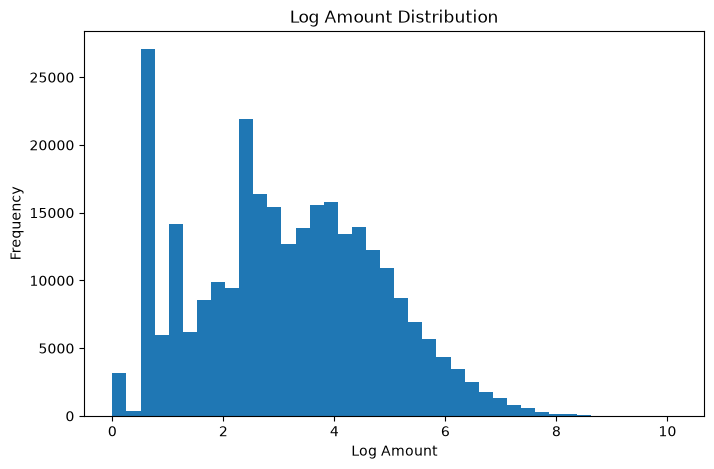

In [52]:
plt.figure(figsize=(8,5))

plt.hist(df["Log_Amount"], bins=40)

plt.title("Log Amount Distribution")

plt.xlabel("Log Amount")

plt.ylabel("Frequency")

plt.show()

## Save Dataset

In [53]:
df.to_csv(
    "../data/processed/creditcard_feature_engineered.csv",
    index=False
)

### Verify

In [54]:
import os

os.path.exists(
    "../data/processed/creditcard_feature_engineered.csv"
)

True

# Final Observations

1. Three additional features were created.

2. Large Transaction identifies transactions in the top 5% by amount.

3. Log Amount reduces skewness in transaction values.

4. Amount Level categorizes transaction amounts into quartiles.

5. Weekend and Hour features were not created because the dataset does not contain actual calendar timestamps.

# Conclusion

Feature engineering enhanced the cleaned dataset by generating additional informative features while avoiding assumptions unsupported by the available data. The engineered dataset is now ready for machine learning preprocessing and model training.

# Remove Temporary Feature

Original_Amount was added only to create feature-engineered columns.
After creating all required features, it is removed to keep the final dataset clean.

In [55]:
df.drop(columns=["Original_Amount"], inplace=True)

In [56]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V24,V25,V26,V27,V28,Amount,Class,Large_Transaction,Log_Amount,Amount_Level
0,-1.996823,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,0.066928,0.128539,-0.189115,0.133558,-0.021053,0.244200,0,0,5.014760,Very High
1,-1.996823,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.339846,0.167170,0.125895,-0.008983,0.014724,-0.342584,0,0,1.305626,Low
2,-1.996802,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,1.158900,0,1,5.939276,Very High
3,-1.996802,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-1.175575,0.647376,-0.221929,0.062723,0.061458,0.139886,0,0,4.824306,Very High
4,-1.996781,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,0.141267,-0.206010,0.502292,0.219422,0.215153,-0.073813,0,0,4.262539,High


## Final Check

In [57]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 283726 entries, 0 to 283725
Data columns (total 34 columns):
 #   Column             Non-Null Count   Dtype   
---  ------             --------------   -----   
 0   Time               283726 non-null  float64 
 1   V1                 283726 non-null  float64 
 2   V2                 283726 non-null  float64 
 3   V3                 283726 non-null  float64 
 4   V4                 283726 non-null  float64 
 5   V5                 283726 non-null  float64 
 6   V6                 283726 non-null  float64 
 7   V7                 283726 non-null  float64 
 8   V8                 283726 non-null  float64 
 9   V9                 283726 non-null  float64 
 10  V10                283726 non-null  float64 
 11  V11                283726 non-null  float64 
 12  V12                283726 non-null  float64 
 13  V13                283726 non-null  float64 
 14  V14                283726 non-null  float64 
 15  V15                283726 non-null  float64 


In [58]:
df.isnull().sum().sum()

np.int64(0)

In [59]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V24,V25,V26,V27,V28,Amount,Class,Large_Transaction,Log_Amount,Amount_Level
0,-1.996823,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,0.066928,0.128539,-0.189115,0.133558,-0.021053,0.244200,0,0,5.014760,Very High
1,-1.996823,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.339846,0.167170,0.125895,-0.008983,0.014724,-0.342584,0,0,1.305626,Low
2,-1.996802,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,1.158900,0,1,5.939276,Very High
3,-1.996802,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-1.175575,0.647376,-0.221929,0.062723,0.061458,0.139886,0,0,4.824306,Very High
4,-1.996781,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,0.141267,-0.206010,0.502292,0.219422,0.215153,-0.073813,0,0,4.262539,High


In [60]:
import os

os.makedirs("../data/processed", exist_ok=True)

df.to_csv("../data/processed/creditcard_feature_engineered.csv", index=False)

In [61]:
import os

os.path.exists("../data/processed/creditcard_feature_engineered.csv")

True